In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# ============================================================
# CELL 2 — LOAD DATASET
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

print("="*60)
print("           TESLA DATASET - OVERVIEW")
print("="*60)
print(f"  Rows        : {df.shape[0]}")
print(f"  Columns     : {df.shape[1]}")
print(f"  Missing vals: {df.isnull().sum().sum()}")
print(f"  Duplicates  : {df.duplicated().sum()}")
print("="*60)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

           TESLA DATASET - OVERVIEW
  Rows        : 2640
  Columns     : 12
  Missing vals: 0
  Duplicates  : 0

Column Names:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

First 5 Rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
# ============================================================
# CELL 3 — DATA TYPES & MISSING VALUES
# ============================================================
print("Data Types:\n")
print(df.dtypes)
print("\nMissing Values per Column:")
print(df.isnull().sum())
print("\nDescriptive Statistics:")
df.describe().round(2)

Data Types:

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

Missing Values per Column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Descriptive Statistics:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


In [5]:
# ============================================================
# CELL 4 — DATA CLEANING
# ============================================================
# Remove duplicates
df.drop_duplicates(inplace=True)

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Fill missing values (forward fill)
df.fillna(method='ffill', inplace=True)

print(f"Shape after cleaning: {df.shape}")
print("Data is clean — no missing values, no duplicates.")

Shape after cleaning: (2640, 12)
Data is clean — no missing values, no duplicates.


In [6]:
# ============================================================
# CELL 5 — FEATURE ENGINEERING
# ============================================================
# Delivery to Production Ratio (%)
df['Delivery_Ratio'] = (df['Estimated_Deliveries'] / df['Production_Units'] * 100).round(2)

# Production Surplus (how many more units produced than delivered)
df['Production_Surplus'] = df['Production_Units'] - df['Estimated_Deliveries']

# Revenue Estimate
df['Revenue_Est_USD'] = df['Estimated_Deliveries'] * df['Avg_Price_USD']

print("New features added:")
print(df[['Year','Model','Estimated_Deliveries','Production_Units',
          'Delivery_Ratio','Production_Surplus','Revenue_Est_USD']].head(8).to_string(index=False))

New features added:
 Year      Model  Estimated_Deliveries  Production_Units  Delivery_Ratio  Production_Surplus  Revenue_Est_USD
 2023    Model S                 17646             17922           98.46                 276     1.638859e+09
 2015    Model X                  3797              4164           91.19                 367     2.361949e+08
 2019    Model X                  8411              9189           91.53                 778     9.915502e+08
 2021    Model 3                  6555              7311           89.66                 756     5.853281e+08
 2016    Model Y                 12374             13537           91.41                1163     1.421114e+09
 2020    Model X                  4656              5043           92.33                 387     4.047487e+08
 2015    Model 3                  7717              7976           96.75                 259     6.759182e+08
 2020 Cybertruck                  8410              9192           91.49                 782     6.2

In [7]:
# ============================================================
# CELL 6 — ANNUAL AGGREGATION
# ============================================================
annual = df.groupby('Year').agg(
    Total_Deliveries   = ('Estimated_Deliveries', 'sum'),
    Total_Production   = ('Production_Units',      'sum'),
    Avg_Price          = ('Avg_Price_USD',          'mean'),
    Total_CO2_Saved    = ('CO2_Saved_tons',         'sum'),
    Total_Revenue_Est  = ('Revenue_Est_USD',        'sum')
).reset_index()

annual['YoY_Growth_%'] = annual['Total_Deliveries'].pct_change() * 100
annual['Del_Ratio_%']  = (annual['Total_Deliveries'] / annual['Total_Production'] * 100).round(2)

print("="*70)
print("ANNUAL SUMMARY TABLE")
print("="*70)
print(annual.round(1).to_string(index=False))

ANNUAL SUMMARY TABLE
 Year  Total_Deliveries  Total_Production  Avg_Price  Total_CO2_Saved  Total_Revenue_Est  YoY_Growth_%  Del_Ratio_%
 2015           2375267           2545695    85684.4         182466.2       2.020542e+11           NaN         93.3
 2016           2434081           2617000    84777.0         185529.9       2.066250e+11           2.5         93.0
 2017           2350517           2527084    85111.4         172837.3       1.971317e+11          -3.4         93.0
 2018           2423104           2598455    86111.9         183804.4       2.081274e+11           3.1         93.2
 2019           2404230           2573522    83990.5         180034.1       2.014564e+11          -0.8         93.4
 2020           2280336           2462234    84159.9         171564.5       1.903011e+11          -5.2         92.6
 2021           2335116           2506114    83270.6         179127.0       1.970671e+11           2.4         93.2
 2022           2434220           2616834    85680.

In [8]:
# ============================================================
# CELL 7 — GROUPED ANALYSIS
# ============================================================
# By Model
print("="*50)
print("DELIVERIES BY MODEL")
print("="*50)
by_model = df.groupby('Model')['Estimated_Deliveries'].agg(['sum','mean','count'])
by_model.columns = ['Total','Average','Count']
print(by_model.sort_values('Total', ascending=False).round(0))

# By Region
print("\n" + "="*50)
print("DELIVERIES BY REGION")
print("="*50)
by_region = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
print(by_region)

# By Year + Model
print("\n" + "="*50)
print("DELIVERIES BY YEAR & MODEL (PIVOT TABLE)")
print("="*50)
pivot_ym = df.pivot_table(
    index='Year', columns='Model',
    values='Estimated_Deliveries', aggfunc='sum'
)
print(pivot_ym.round(0))

# By Region + Model
print("\n" + "="*50)
print("DELIVERIES BY REGION & MODEL")
print("="*50)
pivot_rm = df.pivot_table(
    index='Model', columns='Region',
    values='Estimated_Deliveries', aggfunc='sum'
)
print(pivot_rm.round(0))

DELIVERIES BY MODEL
              Total  Average  Count
Model                              
Model S     5380385  10190.0    528
Model 3     5321919  10079.0    528
Model Y     5225284   9896.0    528
Model X     5157240   9768.0    528
Cybertruck  5109779   9678.0    528

DELIVERIES BY REGION
Region
Middle East      6698045
Asia             6539935
Europe           6494035
North America    6462592
Name: Estimated_Deliveries, dtype: int64

DELIVERIES BY YEAR & MODEL (PIVOT TABLE)
Model  Cybertruck  Model 3  Model S  Model X  Model Y
Year                                                 
2015       430202   523716   510293   437366   473690
2016       475256   467772   523248   485308   482497
2017       492785   473837   464815   439791   479289
2018       426255   519065   486512   480846   510426
2019       461653   509750   518339   460524   453964
2020       467716   463402   479777   434602   434839
2021       481289   451851   479905   460620   461451
2022       436080   487749   4

In [9]:
# ============================================================
# CELL 8 — STATISTICAL ANALYSIS
# ============================================================
print("="*60)
print("CORRELATION MATRIX")
print("="*60)
num_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD',
            'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
corr = df[num_cols].corr()
print(corr.round(3))

# Pearson Correlation: Deliveries vs Production
r, p = stats.pearsonr(df['Estimated_Deliveries'], df['Production_Units'])
print(f"\nPearson r (Deliveries vs Production): {r:.4f}  p-value: {p:.6f}")

# Linear Regression: Year vs Deliveries
slope, intercept, r_val, p_val, std_err = stats.linregress(
    df['Year'], df['Estimated_Deliveries'])
print(f"\nLinear Regression (Year → Deliveries):")
print(f"  Slope     : {slope:.2f} units/year")
print(f"  Intercept : {intercept:.2f}")
print(f"  R²        : {r_val**2:.4f}")
print(f"  p-value   : {p_val:.6f}")

# Linear Regression: Charging Stations vs Deliveries
slope2, intercept2, r2, p2, _ = stats.linregress(
    df['Charging_Stations'], df['Estimated_Deliveries'])
print(f"\nLinear Regression (Charging Stations → Deliveries):")
print(f"  Slope : {slope2:.4f}  |  R²: {r2**2:.4f}  |  p: {p2:.4f}")

CORRELATION MATRIX
                      Estimated_Deliveries  Production_Units  Avg_Price_USD  \
Estimated_Deliveries                 1.000             0.994         -0.028   
Production_Units                     0.994             1.000         -0.029   
Avg_Price_USD                       -0.028            -0.029          1.000   
Battery_Capacity_kWh                -0.008            -0.004         -0.018   
Range_km                            -0.007            -0.003         -0.018   
CO2_Saved_tons                       0.837             0.834         -0.029   
Charging_Stations                    0.001             0.001         -0.018   

                      Battery_Capacity_kWh  Range_km  CO2_Saved_tons  \
Estimated_Deliveries                -0.008    -0.007           0.837   
Production_Units                    -0.004    -0.003           0.834   
Avg_Price_USD                       -0.018    -0.018          -0.029   
Battery_Capacity_kWh                 1.000     0.994        

In [10]:
# ============================================================
# CELL 9 — OUTLIER DETECTION
# ============================================================
print("="*55)
print("OUTLIER DETECTION (IQR METHOD)")
print("="*55)
outlier_summary = []
for col in ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'CO2_Saved_tons', 'Charging_Stations']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    out = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({'Column': col, 'Lower_Bound': round(lower,2),
                             'Upper_Bound': round(upper,2), 'Outlier_Count': len(out)})
    print(f"{col:25s}: {len(out):3d} outliers  |  Range [{lower:.1f}, {upper:.1f}]")

out_df = pd.DataFrame(outlier_summary)
print("\nOutlier Summary:")
print(out_df.to_string(index=False))

OUTLIER DETECTION (IQR METHOD)
Estimated_Deliveries     :  12 outliers  |  Range [-535.4, 20337.6]
Production_Units         :  12 outliers  |  Range [-632.9, 21930.1]
Avg_Price_USD            :   0 outliers  |  Range [15756.3, 154343.1]
CO2_Saved_tons           :  45 outliers  |  Range [-166.6, 1610.0]
Charging_Stations        :   0 outliers  |  Range [-3162.6, 20998.4]

Outlier Summary:
              Column  Lower_Bound  Upper_Bound  Outlier_Count
Estimated_Deliveries      -535.38     20337.62             12
    Production_Units      -632.88     21930.12             12
       Avg_Price_USD     15756.35    154343.06              0
      CO2_Saved_tons      -166.60      1609.98             45
   Charging_Stations     -3162.62     20998.38              0


In [11]:
# ============================================================
# CELL 10 — VISUALIZATIONS (9 Plots)
# ============================================================
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False})

PAL = {'delivery': '#185FA5', 'production': '#1D9E75', 'red': '#E24B4A',
       'purple': '#534AB7', 'orange': '#D85A30'}
MODEL_COLORS = ['#185FA5', '#1D9E75', '#534AB7', '#D85A30', '#E24B4A']
REGION_COLORS = {'North America': '#185FA5', 'Europe': '#1D9E75',
                 'Asia': '#D85A30', 'Middle East': '#534AB7'}

fig = plt.figure(figsize=(20, 15))
fig.suptitle('Tesla Deliveries & Production — Full Analysis (2015–2025)',
             fontsize=17, fontweight='bold', y=0.99)

Text(0.5, 0.99, 'Tesla Deliveries & Production — Full Analysis (2015–2025)')

<Figure size 2600x1950 with 0 Axes>

In [12]:
# --- 1. Annual Deliveries vs Production ---
ax1 = fig.add_subplot(3, 3, 1)
x = np.arange(len(annual)); w = 0.38
ax1.bar(x - w/2, annual['Total_Deliveries']/1e6, w,
        label='Deliveries', color=PAL['delivery'], alpha=0.85)
ax1.bar(x + w/2, annual['Total_Production']/1e6, w,
        label='Production', color=PAL['production'], alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(annual['Year'], rotation=45, fontsize=8)
ax1.set_title('Annual Deliveries vs Production', fontweight='bold')
ax1.set_ylabel('Units (Millions)')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

In [13]:
# --- 2. YoY Growth ---
ax2 = fig.add_subplot(3, 3, 2)
growth = annual['YoY_Growth_%'].dropna()
yrs    = annual['Year'][annual['YoY_Growth_%'].notna()]
bar_c  = [PAL['delivery'] if g >= 0 else PAL['red'] for g in growth]
bars   = ax2.bar(yrs, growth, color=bar_c, alpha=0.85, width=0.6)
ax2.axhline(0, color='gray', lw=0.8, linestyle='--')
ax2.set_title('Year-over-Year Delivery Growth (%)', fontweight='bold')
ax2.set_ylabel('Growth (%)')
for bar, val in zip(bars, growth):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (0.1 if val >= 0 else -0.3),
             f'{val:.1f}%', ha='center', fontsize=7)
ax2.set_xticks(yrs)
ax2.set_xticklabels(yrs, rotation=45, fontsize=8)
ax2.grid(axis='y', alpha=0.3)

In [14]:
# --- 3. Deliveries by Model (Pie) ---
ax3 = fig.add_subplot(3, 3, 3)
by_model_sum = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
wedges, texts, autotexts = ax3.pie(
    by_model_sum, labels=by_model_sum.index,
    autopct='%1.1f%%', colors=MODEL_COLORS,
    startangle=140, textprops={'fontsize': 8})
ax3.set_title('Deliveries by Model', fontweight='bold')

Text(0.5, 1.0, 'Deliveries by Model')

In [15]:
# --- 4. Deliveries by Region (Horizontal Bar) ---
ax4 = fig.add_subplot(3, 3, 4)
by_region_plot = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values()
ax4.barh(by_region_plot.index, by_region_plot.values/1e6,
         color=MODEL_COLORS[:4], alpha=0.85)
ax4.set_title('Total Deliveries by Region', fontweight='bold')
ax4.set_xlabel('Units (Millions)')
for i, v in enumerate(by_region_plot.values):
    ax4.text(v/1e6 + 0.01, i, f'{v/1e6:.2f}M', va='center', fontsize=8)
ax4.grid(axis='x', alpha=0.3)

In [16]:
# --- 5. Correlation Heatmap ---
ax5 = fig.add_subplot(3, 3, 5)
short_labels = ['Deliveries', 'Production', 'Price', 'Battery', 'Range', 'CO2']
corr_plot = df[['Estimated_Deliveries','Production_Units','Avg_Price_USD',
                'Battery_Capacity_kWh','Range_km','CO2_Saved_tons']].corr()
sns.heatmap(corr_plot, annot=True, fmt='.2f', cmap='Blues', ax=ax5,
            xticklabels=short_labels, yticklabels=short_labels,
            linewidths=0.5, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 7})
ax5.set_title('Correlation Heatmap', fontweight='bold')
ax5.tick_params(axis='x', rotation=45, labelsize=7)
ax5.tick_params(axis='y', rotation=0, labelsize=7)

In [17]:
# --- 6. Avg Price Boxplot by Model ---
ax6 = fig.add_subplot(3, 3, 6)
data_bp = [df[df['Model'] == m]['Avg_Price_USD'].values
           for m in sorted(df['Model'].unique())]
bp = ax6.boxplot(data_bp, patch_artist=True,
                 labels=sorted(df['Model'].unique()))
for patch, color in zip(bp['boxes'], MODEL_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax6.set_title('Avg Price Distribution by Model', fontweight='bold')
ax6.set_ylabel('Price (USD)')
ax6.tick_params(axis='x', rotation=30, labelsize=8)
ax6.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'${int(v/1000)}k'))
ax6.grid(axis='y', alpha=0.3)

In [18]:
# --- 7. CO2 Saved Per Year ---
ax7 = fig.add_subplot(3, 3, 7)
co2_annual = df.groupby('Year')['CO2_Saved_tons'].sum()
ax7.fill_between(co2_annual.index, co2_annual.values/1e3,
                 alpha=0.25, color=PAL['production'])
ax7.plot(co2_annual.index, co2_annual.values/1e3,
         color=PAL['production'], lw=2, marker='o', ms=5)
ax7.set_title('Total CO₂ Saved Per Year (K tons)', fontweight='bold')
ax7.set_ylabel('CO₂ Saved (K tons)')
ax7.set_xticks(co2_annual.index)
ax7.set_xticklabels(co2_annual.index, rotation=45, fontsize=8)
ax7.grid(alpha=0.3)

In [19]:
# --- 8. Model × Region Heatmap ---
ax8 = fig.add_subplot(3, 3, 8)
pivot = df.pivot_table(index='Model', columns='Region',
                       values='Estimated_Deliveries', aggfunc='sum')
sns.heatmap(pivot/1e3, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax8,
            cbar_kws={'shrink': 0.7, 'label': '(K units)'},
            annot_kws={'size': 8})
ax8.set_title('Deliveries: Model × Region (K units)', fontweight='bold')
ax8.tick_params(axis='x', rotation=30, labelsize=8)
ax8.tick_params(axis='y', rotation=0, labelsize=8)

In [20]:
# --- 9. Charging Stations vs Deliveries (Scatter) ---
ax9 = fig.add_subplot(3, 3, 9)
for region, grp in df.groupby('Region'):
    ax9.scatter(grp['Charging_Stations'], grp['Estimated_Deliveries']/1e3,
                alpha=0.2, s=12, color=REGION_COLORS[region], label=region)
# Regression line
m_cs, b_cs, _, _, _ = stats.linregress(
    df['Charging_Stations'], df['Estimated_Deliveries']/1e3)
x_line = np.linspace(df['Charging_Stations'].min(),
                     df['Charging_Stations'].max(), 100)
ax9.plot(x_line, m_cs*x_line + b_cs, color='black', lw=1.5, linestyle='--', label='Trend')
ax9.set_title('Charging Stations vs Deliveries', fontweight='bold')
ax9.set_xlabel('Charging Stations')
ax9.set_ylabel('Deliveries (K units)')
ax9.legend(fontsize=7, markerscale=1.5)
ax9.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('tesla_full_analysis.png', bbox_inches='tight', facecolor='white')
plt.show()
print("All 9 plots saved as tesla_full_analysis.png")


<Figure size 832x624 with 0 Axes>

All 9 plots saved as tesla_full_analysis.png


DELIVERY FORECAST (Polynomial Regression - Degree 2)
  2026 Forecast:    2,402,485 deliveries
  2027 Forecast:    2,414,774 deliveries


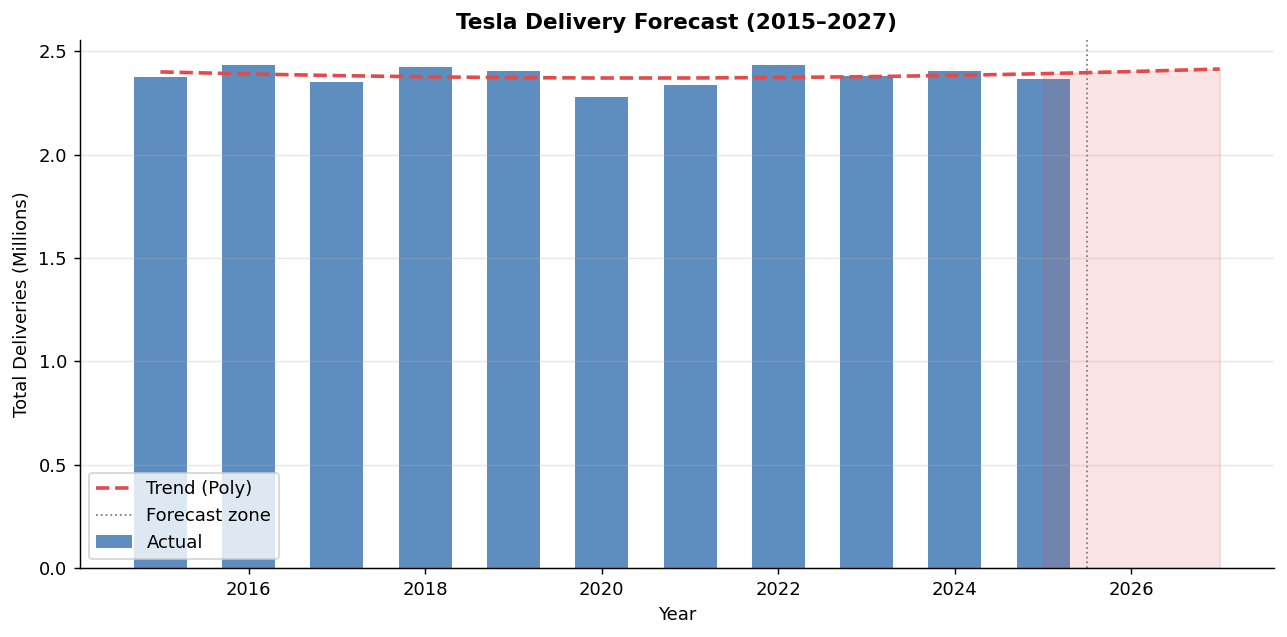

Forecast plot saved as tesla_forecast.png


In [21]:
# ============================================================
# CELL 11 — FORECAST (Polynomial Trend)
# ============================================================
print("="*55)
print("DELIVERY FORECAST (Polynomial Regression - Degree 2)")
print("="*55)
coefs = np.polyfit(annual['Year'], annual['Total_Deliveries'], deg=2)
for yr in [2026, 2027]:
    fc = int(np.polyval(coefs, yr))
    print(f"  {yr} Forecast: {fc:>12,} deliveries")

# Forecast Plot
fig2, ax = plt.subplots(figsize=(10, 5))
x_hist = annual['Year'].values
y_hist = annual['Total_Deliveries'].values
x_fut  = np.arange(2015, 2028)
y_fit  = np.polyval(coefs, x_fut)

ax.bar(x_hist, y_hist/1e6, color=PAL['delivery'], alpha=0.7, label='Actual', width=0.6)
ax.plot(x_fut, y_fit/1e6, color=PAL['red'], lw=2, linestyle='--', label='Trend (Poly)')
ax.axvline(2025.5, color='gray', lw=1, linestyle=':', label='Forecast zone')
ax.fill_between(x_fut[x_fut >= 2025], y_fit[x_fut >= 2025]/1e6,
                alpha=0.15, color=PAL['red'])
ax.set_title('Tesla Delivery Forecast (2015–2027)', fontweight='bold')
ax.set_ylabel('Total Deliveries (Millions)')
ax.set_xlabel('Year')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('tesla_forecast.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Forecast plot saved as tesla_forecast.png")

In [22]:
# ============================================================
# CELL 12 — FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("           FINAL SUMMARY")
print("="*60)
print(f"  Total Rows Analysed  : {len(df):,}")
print(f"  Years Covered        : {df['Year'].min()} – {df['Year'].max()}")
print(f"  Models               : {', '.join(sorted(df['Model'].unique()))}")
print(f"  Regions              : {', '.join(sorted(df['Region'].unique()))}")
print(f"  Avg Delivery/Row     : {df['Estimated_Deliveries'].mean():,.0f} units")
print(f"  Peak Year (deliveries): {annual.loc[annual['Total_Deliveries'].idxmax(), 'Year']}")
print(f"  Avg Price Overall    : ${df['Avg_Price_USD'].mean():,.0f}")
print(f"  Total CO2 Saved      : {df['CO2_Saved_tons'].sum()/1e6:.2f}M tons")
print(f"  Corr Deliveries↔Prod : {df['Estimated_Deliveries'].corr(df['Production_Units']):.4f}")
print("="*60)
print("Analysis Complete!")


           FINAL SUMMARY
  Total Rows Analysed  : 2,640
  Years Covered        : 2015 – 2025
  Models               : Cybertruck, Model 3, Model S, Model X, Model Y
  Regions              : Asia, Europe, Middle East, North America
  Avg Delivery/Row     : 9,922 units
  Peak Year (deliveries): 2022
  Avg Price Overall    : $84,907
  Total CO2 Saved      : 1.96M tons
  Corr Deliveries↔Prod : 0.9942
Analysis Complete!
